In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import altair as alt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("data/application_history_v3.csv")

# Clean Data, Feature Engineer

In [4]:
# create an indicator for homeless students (based on client input)
df['is_homeless'] = (df['STUDISTFROMSCHOOLINMILES'] == 0.0) | (df['NumStudInHouseholdApplying'] == 209)

In [5]:
# bin grades by school type
school_grade_map = {
    'Pre-Kindergarten': ['4K', "Y 5's"], 
    'Elementary School': ['K','1', '2', '3', '4', '5'],
    'Middle School': ['6', '7', '8'], 
    'High School': ['9', '10', '11', '12']}

# map grade levels to school types
grade_to_school = {
    grade: school
    for school, grades in school_grade_map.items()
    for grade in grades
}

df["school_type"] = df["GradeAbbreviation"].map(grade_to_school)

In [6]:
# correct number of students applying from the same household (mainly for homeless students)
def correct_household_num(row):
    if row['is_homeless']:
        row['num_students_in_hh_cleaned'] = np.NaN # There are no 0s, just NaNs
    else:
        row['num_students_in_hh_cleaned'] = row['NumStudInHouseholdApplying']
    return row

# apply correction function, which will create a new column
df = df.apply(correct_household_num, axis=1)

# fill in missing values
df['num_students_in_hh_cleaned'] = df['num_students_in_hh_cleaned'].fillna(df['num_students_in_hh_cleaned'].median())

In [7]:
# Remove outliers from STUDISTFROMSCHOOLINMILES, based on client input
# Calculate 2 median distances: one broken down by school and one overall one
school_stats = (
    df
    .groupby("SchoolDWID")['STUDISTFROMSCHOOLINMILES']
    .agg(['median', 'count'])
)

min_samples = 5 # Minimum number of samples to obtain median

median_distance_by_school = (
    school_stats.loc[school_stats['count'] >= min_samples, 'median']
)

Q1 = df['STUDISTFROMSCHOOLINMILES'].quantile(0.25)
Q3 = df['STUDISTFROMSCHOOLINMILES'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR  # standard outlier threshold

overall_median_distance = df.loc[
    df['STUDISTFROMSCHOOLINMILES'].notna() &
    (df['STUDISTFROMSCHOOLINMILES'] <= upper_bound),
    'STUDISTFROMSCHOOLINMILES'
].median()

invalid_mask = (
    df['STUDISTFROMSCHOOLINMILES'].isna() |
    (df['STUDISTFROMSCHOOLINMILES'] > upper_bound)
)

df['distance_from_school_imputed'] = df['STUDISTFROMSCHOOLINMILES']

# Only maps to schools that passed the min_samples filter
df.loc[invalid_mask, 'distance_from_school_imputed'] = (
    df.loc[invalid_mask, 'SchoolDWID']
    .map(median_distance_by_school)
)

# Fallback to overall median
df['distance_from_school_imputed'] = (
    df['distance_from_school_imputed']
    .fillna(overall_median_distance)
)

df['distance_from_school_imputed'].describe()

count    227641.000000
mean          4.168262
std           2.837361
min           0.000000
25%           2.164535
50%           3.480388
75%           5.470022
max          14.296481
Name: distance_from_school_imputed, dtype: float64

In [8]:
# Define used columns
# Exclude "Enrolled" to observe patterns leading to enrollment
columns_needed = ["AppNumRankForYearAndSchool", "F_NumberSchoolsAppliedCount", 
                  "num_students_in_hh_cleaned", "SiblingCurrentlyEnrolled", 
                  'WasAccepted', 'AcceptedAtLottery', 'WasRegistered', 'WentNA',
                  'NumberSchoolsRegisteredCount', 'NumberSchoolsAcceptedCount',
                  'AccDaysBeforeSchoolStart', 'RegDaysBeforeSchoolStart', 'AppdaysBeforeSchoolStart',
                  'StartedInFirstWeek', 'StillEnrolledOnStartDatePlus7', 'Enrolled',
                  "CurrentUrbanCentricSchoolDesigna", "is_homeless", 'distance_from_school_imputed',
                  "GradeAbbreviation", 'school_type']

clustering_df = df[columns_needed].copy()

In [9]:
# Assume missing values in StartedInFirstWeek & StillEnrolledOnStartDatePlus7 mean False
clustering_df[['StartedInFirstWeek', 'StillEnrolledOnStartDatePlus7']] = clustering_df[['StartedInFirstWeek', 
                                                                                        'StillEnrolledOnStartDatePlus7']].fillna(0)

In [10]:
# Fill in missing values with 999 for AccDaysBeforeSchoolStart & RegDaysBeforeSchoolStart + create missing indicator
for col in ['AccDaysBeforeSchoolStart', 'RegDaysBeforeSchoolStart']:
    # Indicator for missing
    clustering_df[col + '_missing'] = df[col].isna().astype(int)
    # Impute with 0
    clustering_df[col] = clustering_df[col].fillna(999)

# Preprocessing

In [11]:
# Feature splits
numeric_features = clustering_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = clustering_df.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## Find optimal number of clusters

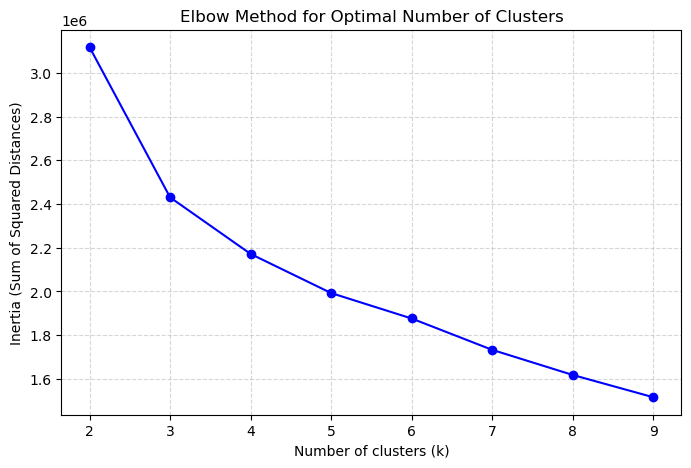

In [15]:
pca = PCA(n_components=0.90, svd_solver='full')

# Step 1: Preprocess + PCA (once)
X_transformed = pca.fit_transform(preprocessor.fit_transform(clustering_df))

# Step 2: Compute inertia for different cluster counts
inertia = []
k_range = range(2, 10)  # you can adjust the range

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_transformed)
    inertia.append(km.inertia_)

# Step 3: Plot the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'o-', color='blue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Cluster Applicants

In [16]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('pca', PCA(n_components=2, svd_solver='full')),
    ('kmeans', KMeans(n_clusters=4, random_state=42, n_init=10))
])

pipeline.fit(clustering_df)
clustering_df['cluster'] = pipeline.named_steps['kmeans'].labels_

cluster_summary = clustering_df.groupby('cluster').mean(numeric_only=True)

# Get cluster sizes
clustering_df['cluster'].value_counts().sort_index()
print(clustering_df.groupby('cluster').size())

cluster
0    97566
1    51389
2    46435
3    32251
dtype: int64


In [17]:
# View cluster summary
print(cluster_summary)

         AppNumRankForYearAndSchool  F_NumberSchoolsAppliedCount  \
cluster                                                            
0                          1.087469                     1.390136   
1                          1.078246                     1.121115   
2                          1.039388                     1.487908   
3                          1.104524                     1.253760   

         num_students_in_hh_cleaned  SiblingCurrentlyEnrolled  WasAccepted  \
cluster                                                                      
0                          1.629328                  0.083185      0.99998   
1                          1.631341                  0.866937      1.00000   
2                          1.520879                  0.027285      0.00000   
3                          1.603113                  0.339617      1.00000   

         AcceptedAtLottery  WasRegistered    WentNA  \
cluster                                               
0           

## Applicant Journey Cluster Profiles

After preprocessing and dimensionality reduction via PCA (2 components),
K-Means clustering (k=4, random_state=42, n_init=10) identified four distinct
applicant journey archetypes.

---

### Cluster 1 — *The Ghost Acceptee* (n = 97,566 | 43.0%)
These applicants were almost universally accepted (≈100%) but took virtually
no action afterward — only 0.009% registered and 0.3% enrolled. Nearly three
quarters went No Action (WentNA = 74.5%). Acceptance timing data is present
(AccDays ≈ 93), but registration timing is entirely missing (sentinel = 999),
confirming they never reached that stage. Sibling enrollment is low (8%),
suggesting limited prior connection to the school. They apply to more schools
than Cluster 2 (1.39 avg), pointing to a broad search strategy where this
school was unlikely a top priority.

**Archetype:** Accepted but walked away — likely committed to another school or
simply never followed through.

---

### Cluster 2 — *The Committed Enrollee* (n = 51,389 | 22.7%)
The highest-quality conversion cluster. Every applicant was accepted, registered,
and enrolled (100% at each stage). 99% started in the first week and 97.6% were
still enrolled at +7 days. Registration occurred ~94 days before school start,
reflecting deliberate and timely decision-making. Sibling enrollment is by far
the highest of any cluster (87%), indicating strong family familiarity with the
school. Applied to the fewest schools overall (1.12 avg), suggesting this was
their clear first choice.

**Archetype:** Fully committed — family-connected, focused, and followed through
at every step.

---

### Cluster 3 — *The Never Accepted Applicant* (n = 46,435 | 20.5%)
This cluster is defined by a complete absence of acceptance — 0% were accepted,
0% enrolled, and all acceptance/registration timing data is missing (both
missing flags = 1.0). Despite this, WentNA is only 20.7%, suggesting many did
not formally go No Action but simply never received an offer. They live the
furthest from school on average (distance = 5.16) and apply to the most schools
(1.49 avg). This group captures applicants who were blocked by lottery or
eligibility, not by lack of intent.

**Archetype:** Wanted in but never got an offer — lottery-blocked or ineligible,
not disengaged.

---

### Cluster 4 — *The Partial Converter* (n = 32,251 | 14.2%)
These applicants were accepted (100%) and over half registered (59%), but
conversion drops sharply at enrollment (41.7%), and further at week 1 (17.1%)
and +7 days (16.6%). WentNA = 43% despite registration activity, indicating
significant mid-funnel drop-off. Registration timing is mixed — about 41% have
real registration dates while 59% have the sentinel value — suggesting a subset
registered at one school but not this one. Sibling enrollment rate is moderate
(34%). Applied to more schools than Cluster 2 (1.25 avg), suggesting they were
considering multiple options and this school was not always the final choice.

**Archetype:** Accepted and partially engaged — attrition happens at every stage
after acceptance, pointing to competing offers or waning commitment.

---

### Summary Table

| Cluster | Label | n | % of Total | Accepted | Registered | Enrolled | Week 1 | Still +7d |
|---------|-------|---|------------|----------|------------|----------|--------|-----------|
| 1 | Ghost Acceptee | 97,566 | 43.0% | ≈100% | <1% | <1% | <1% | <1% |
| 2 | Committed Enrollee | 51,389 | 22.7% | 100% | 100% | 100% | 99% | 98% |
| 3 | Never Accepted | 46,435 | 20.5% | 0% | <1% | 0% | 0% | 0% |
| 4 | Partial Converter | 32,251 | 14.2% | 100% | 59% | 42% | 17% | 17% |

## Static Cluster Viz
Simple viz to see distinguished clusters

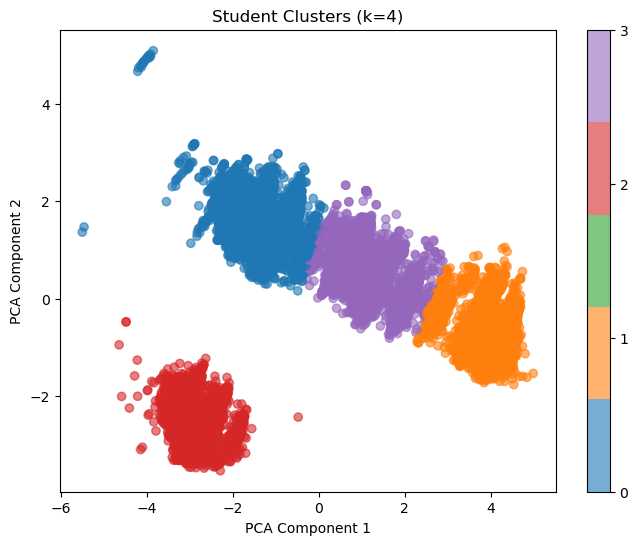

In [14]:
X_2d = pipeline.named_steps['pca'].transform(
    pipeline.named_steps['preprocessing'].transform(clustering_df)
)

# Create a colormap with 5 distinct colors
cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'])

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_2d[:,0], X_2d[:,1],
    c=clustering_df['cluster'],
    cmap=cmap,
    alpha=0.6
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Student Clusters (k=4)')
plt.colorbar(scatter, ticks=range(4))
plt.show()